# Exploratory Data Analysis (EDA) & Missing Value Treatment

Exploratory Data Analysis (EDA) is the process of analyzing datasets to summarize their main characteristics, often with visual methods. This notebook covers:
*   Handling missing values (`dropna` vs `fillna` decisions)
*   Imputation strategies (using mean vs median depending on outlier presence)
*   Feature relationships (fare amount vs time components)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("uber.csv")

In [3]:
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


# About Dataset
  Here we are going to analyze fare amount with respect to hours ,week_days,month,year,passenger_count

In [4]:
# shape
rows,cols=df.shape

In [5]:
print(f" Row:{rows}\n Cloumns:{cols}")

 Row:200000
 Cloumns:9


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


In [7]:
df.isna().sum()

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

In [8]:
df = df.drop_duplicates()

In [9]:
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


## When to use Dropna?  
   o if cloumn contains <= 5-10% missing values      
   o if 70% missing values drop the column or replace with zero        
   o 

o-if columns have outliers then we should not use mean to fill null values      
o-use mean when column does not have outliers

In [10]:
df["pickup_datetime"]

0         2015-05-07 19:52:06 UTC
1         2009-07-17 20:04:56 UTC
2         2009-08-24 21:45:00 UTC
3         2009-06-26 08:22:21 UTC
4         2014-08-28 17:47:00 UTC
                   ...           
199995    2012-10-28 10:49:00 UTC
199996    2014-03-14 01:09:00 UTC
199997    2009-06-29 00:42:00 UTC
199998    2015-05-20 14:56:25 UTC
199999    2010-05-15 04:08:00 UTC
Name: pickup_datetime, Length: 200000, dtype: object

In [11]:
df['fare_amount'].mode()

0    6.5
Name: fare_amount, dtype: float64

In [12]:
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [13]:
df=df[df["fare_amount"]>0]


In [14]:
df[df["key"]!=df["pickup_datetime"]]

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5
...,...,...,...,...,...,...,...,...,...
199995,42598914,2012-10-28 10:49:00.00000053,3.0,2012-10-28 10:49:00 UTC,-73.987042,40.739367,-73.986525,40.740297,1
199996,16382965,2014-03-14 01:09:00.0000008,7.5,2014-03-14 01:09:00 UTC,-73.984722,40.736837,-74.006672,40.739620,1
199997,27804658,2009-06-29 00:42:00.00000078,30.9,2009-06-29 00:42:00 UTC,-73.986017,40.756487,-73.858957,40.692588,2
199998,20259894,2015-05-20 14:56:25.0000004,14.5,2015-05-20 14:56:25 UTC,-73.997124,40.725452,-73.983215,40.695415,1


In [15]:
df["key"]=pd.to_datetime(df["key"])

In [16]:
df["Year"]=df["key"].dt.year
df["Month"]=df["key"].dt.month
df["Day"]=df["key"].dt.day
# df['Time']=df["key"].dt.time
df["Hour"]=df["key"].dt.hour


In [17]:
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,Year,Month,Day,Hour
0,24238194,2015-05-07 19:52:06.000000300,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,19
1,27835199,2009-07-17 20:04:56.000000200,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,20
2,44984355,2009-08-24 21:45:00.000000610,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,21
3,25894730,2009-06-26 08:22:21.000000100,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,8
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,17


In [18]:
df.drop(columns= 'year',inplace=True)

KeyError: "['year'] not found in axis"

In [ ]:
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,Time,Year,Month,Day,Hour
0,24238194,2015-05-07 19:52:06.000000300,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,19:52:06,2015,5,7,19
1,27835199,2009-07-17 20:04:56.000000200,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,20:04:56,2009,7,17,20
2,44984355,2009-08-24 21:45:00.000000610,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,21:45:00,2009,8,24,21
3,25894730,2009-06-26 08:22:21.000000100,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,08:22:21,2009,6,26,8
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,17:47:00,2014,8,28,17


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 199971 entries, 0 to 199999
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   Unnamed: 0         199971 non-null  int64              
 1   key                199971 non-null  datetime64[ns]     
 2   fare_amount        199971 non-null  float64            
 3   pickup_datetime    199971 non-null  datetime64[ns, UTC]
 4   pickup_longitude   199971 non-null  float64            
 5   pickup_latitude    199971 non-null  float64            
 6   dropoff_longitude  199970 non-null  float64            
 7   dropoff_latitude   199970 non-null  float64            
 8   passenger_count    199971 non-null  int64              
 9   Time               199971 non-null  object             
 10  Year               199971 non-null  int32              
 11  Month              199971 non-null  int32              
 12  Day                199971 non-null 

In [ ]:
df.columns

Index(['key', 'fare_amount', 'pickup_datetime', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'passenger_count', 'Time', 'Year', 'Month', 'Day', 'Hour'],
      dtype='object')

In [ ]:
df.drop('Unnamed: 0',axis=1,inplace=True)

KeyError: "['Unnamed: 0'] not found in axis"

In [ ]:
df.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,Time,Year,Month,Day,Hour
0,2015-05-07 19:52:06.000000300,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,19:52:06,2015,5,7,19
1,2009-07-17 20:04:56.000000200,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,20:04:56,2009,7,17,20
2,2009-08-24 21:45:00.000000610,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,21:45:00,2009,8,24,21
3,2009-06-26 08:22:21.000000100,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,08:22:21,2009,6,26,8
4,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,17:47:00,2014,8,28,17


In [ ]:
df[df['passenger_count']<0]

In [ ]:
df=df[df['fare_amount']>0]

# Analyz the data and give 20 conclutions

In [ ]:
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,Year,Month,Day,Hour
0,24238194,2015-05-07 19:52:06.000000300,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,19
1,27835199,2009-07-17 20:04:56.000000200,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,20
2,44984355,2009-08-24 21:45:00.000000610,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,21
3,25894730,2009-06-26 08:22:21.000000100,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,8
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,17


# 1. The data set is about uber rides 

In [ ]:
# 2.  Number of columns and rows

print("Rows:",df.shape[0])
print("Columns:",df.shape[1])

Rows: 199978
Columns: 13


In [ ]:
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,Year,Month,Day,Hour
0,24238194,2015-05-07 19:52:06.000000300,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,19
1,27835199,2009-07-17 20:04:56.000000200,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,20
2,44984355,2009-08-24 21:45:00.000000610,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,21
3,25894730,2009-06-26 08:22:21.000000100,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,8
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,17


In [ ]:
# 3.types of columns
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 199978 entries, 0 to 199999
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Unnamed: 0         199978 non-null  int64         
 1   key                199978 non-null  datetime64[ns]
 2   fare_amount        199978 non-null  float64       
 3   pickup_datetime    199978 non-null  object        
 4   pickup_longitude   199978 non-null  float64       
 5   pickup_latitude    199978 non-null  float64       
 6   dropoff_longitude  199977 non-null  float64       
 7   dropoff_latitude   199977 non-null  float64       
 8   passenger_count    199978 non-null  int64         
 9   Year               199978 non-null  int32         
 10  Month              199978 non-null  int32         
 11  Day                199978 non-null  int32         
 12  Hour               199978 non-null  int32         
dtypes: datetime64[ns](1), float64(5), int32(4), int64

In [ ]:
df.isna().sum()
# 4.one null in dropoff_longitude and dropoff_latitude

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
Year                 0
Month                0
Day                  0
Hour                 0
dtype: int64

In [ ]:
df.columns
coll=['Unnamed: 0', 'key', 'fare_amount', 'pickup_datetime',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'passenger_count', 'Year', 'Month', 'Day', 'Hour']
for col in coll:
    print(col,":",df[col].dtype)

Unnamed: 0 : int64
key : datetime64[ns]
fare_amount : float64
pickup_datetime : object
pickup_longitude : float64
pickup_latitude : float64
dropoff_longitude : float64
dropoff_latitude : float64
passenger_count : int64
Year : int32
Month : int32
Day : int32
Hour : int32


In [ ]:
# Types of columns
df[coll].dtypes

Unnamed: 0                    int64
key                  datetime64[ns]
fare_amount                 float64
pickup_datetime              object
pickup_longitude            float64
pickup_latitude             float64
dropoff_longitude           float64
dropoff_latitude            float64
passenger_count               int64
Year                          int32
Month                         int32
Day                           int32
Hour                          int32
dtype: object

In [ ]:
# 5.Duplicate records
df[df.duplicated()]

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,Year,Month,Day,Hour


In [ ]:
df.describe()

,Unnamed: 0,key,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,Year,Month,Day,Hour
count,1.999780e+05,199978,199978.000000,199978.000000,199978.000000,199977.000000,199977.000000,199978.000000,199978.000000,199978.000000,199978.000000,199978.000000
mean,2.771229e+07,2012-03-22 14:08:03.544570368,11.362649,-72.527851,39.935999,-72.526243,39.924410,1.684480,2011.742307,6.282146,15.705003,13.491399
min,1.000000e+00,2009-01-01 01:15:22.000000600,0.010000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000,2009.000000,1.000000,1.000000,0.000000
25%,1.382519e+07,2010-08-25 09:17:00,6.000000,-73.992065,40.734795,-73.991407,40.733825,1.000000,2010.000000,3.000000,8.000000,9.000000
50%,2.774518e+07,2012-03-21 20:28:03.500000512,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000,2012.000000,6.000000,16.000000,14.000000
75%,4.155540e+07,2013-10-19 01:02:24.250000384,12.500000,-73.967155,40.767158,-73.963659,40.768001,2.000000,2013.000000,9.000000,23.000000,19.000000
max,5.542357e+07,2015-06-30 23:40:39.000000100,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000,2015.000000,12.000000,31.000000,23.000000
std,1.601400e+07,NaN,9.897079,11.437257,7.720443,13.115114,6.793438,1.385974,1.856277,3.438924,8.687539,6.515409


In [ ]:
df["passenger_count"].unique()
# 6.  0 and 208 are invalid

array([  1,   3,   5,   2,   4,   6,   0, 208], dtype=int64)

In [ ]:
for col in coll:
    print(col)
    print(df[col].nunique())
    print()

Unnamed: 0
199978

key
199975

fare_amount
1230

pickup_datetime
196607

pickup_longitude
71059

pickup_latitude
83828

dropoff_longitude
76890

dropoff_latitude
90579

passenger_count
8

Year
7

Month
12

Day
31

Hour
24



In [ ]:
# 7 .maximum and 8.minimum in fare amount
print("Max Fare Amount:",df["fare_amount"].max())
print("Minimum Fare Amount:",df["fare_amount"].min())




Max Fare Amount: 499.0
Minimum Fare Amount: 0.01


In [ ]:
df.head(1)

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,Year,Month,Day,Hour
0,24238194,2015-05-07 19:52:06.000000300,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,19


In [ ]:
#8 . Maximum and Minimum number of passenger
print("Max Passenger:",df["passenger_count"].max())
print("Minimum Passenger:",df["passenger_count"].min())

Max Passenger: 208
Minimum Passenger: 0


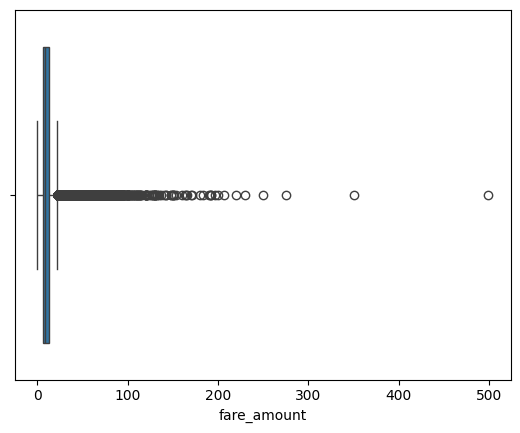

In [ ]:
# 9 Outliers in fare amount 
sns.boxplot(x=df['fare_amount'])
plt.show()

In [ ]:
year_grp=df.groupby('Year')

In [ ]:
year_grp.get_group(2012)

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,Year,Month,Day,Hour
7,44195482,2012-12-11 13:52:00.000000290,2.5,2012-12-11 13:52:00 UTC,0.000000,0.000000,0.000000,0.000000,1,2012,12,11,13
8,15822268,2012-02-17 09:32:00.000000430,9.7,2012-02-17 09:32:00 UTC,-73.975187,40.745767,-74.002720,40.743537,1,2012,2,17,9
9,50611056,2012-03-29 19:06:00.000000273,12.5,2012-03-29 19:06:00 UTC,-74.001065,40.741787,-73.963040,40.775012,1,2012,3,29,19
15,46272151,2012-02-21 09:33:00.000000280,9.7,2012-02-21 09:33:00 UTC,-73.990718,40.751920,-73.973053,40.744230,2,2012,2,21,9
27,41229643,2012-11-21 17:37:19.000000200,12.0,2012-11-21 17:37:19 UTC,-73.993909,40.741551,-73.987874,40.770232,1,2012,11,21,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...
199973,13381290,2012-11-07 17:53:00.000000145,7.0,2012-11-07 17:53:00 UTC,-73.963912,40.765222,-73.950372,40.783622,2,2012,11,7,17
199977,21117828,2012-11-20 21:04:30.000000100,43.5,2012-11-20 21:04:30 UTC,-73.996671,40.737483,-73.867758,40.897563,1,2012,11,20,21
199980,9899790,2012-10-22 11:18:32.000000100,10.0,2012-10-22 11:18:32 UTC,-73.955423,40.764243,-73.985871,40.769660,1,2012,10,22,11
199993,28359558,2012-09-29 19:51:27.000000600,9.5,2012-09-29 19:51:27 UTC,-73.987798,40.721210,-73.980960,40.744388,1,2012,9,29,19


In [ ]:
df['Year'].mode()

0    2012
Name: Year, dtype: int32

# 1. Dataset Shape

In [ ]:
df.shape

(199978, 13)

# 2. Column Names & Types

In [ ]:
df.dtypes

Unnamed: 0                    int64
key                  datetime64[ns]
fare_amount                 float64
pickup_datetime              object
pickup_longitude            float64
pickup_latitude             float64
dropoff_longitude           float64
dropoff_latitude            float64
passenger_count               int64
Year                          int32
Month                         int32
Day                           int32
Hour                          int32
dtype: object

# 3. Missing Values

In [ ]:
df.isnull().sum()

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
Year                 0
Month                0
Day                  0
Hour                 0
dtype: int64

# 4. Duplicate Rows

In [ ]:
df.duplicated().sum()

0

# 5. Statistical Summary

In [ ]:
df.describe()

,Unnamed: 0,key,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,Year,Month,Day,Hour
count,1.999780e+05,199978,199978.000000,199978.000000,199978.000000,199977.000000,199977.000000,199978.000000,199978.000000,199978.000000,199978.000000,199978.000000
mean,2.771229e+07,2012-03-22 14:08:03.544570368,11.362649,-72.527851,39.935999,-72.526243,39.924410,1.684480,2011.742307,6.282146,15.705003,13.491399
min,1.000000e+00,2009-01-01 01:15:22.000000600,0.010000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000,2009.000000,1.000000,1.000000,0.000000
25%,1.382519e+07,2010-08-25 09:17:00,6.000000,-73.992065,40.734795,-73.991407,40.733825,1.000000,2010.000000,3.000000,8.000000,9.000000
50%,2.774518e+07,2012-03-21 20:28:03.500000512,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000,2012.000000,6.000000,16.000000,14.000000
75%,4.155540e+07,2013-10-19 01:02:24.250000384,12.500000,-73.967155,40.767158,-73.963659,40.768001,2.000000,2013.000000,9.000000,23.000000,19.000000
max,5.542357e+07,2015-06-30 23:40:39.000000100,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000,2015.000000,12.000000,31.000000,23.000000
std,1.601400e+07,NaN,9.897079,11.437257,7.720443,13.115114,6.793438,1.385974,1.856277,3.438924,8.687539,6.515409


# 6. Invalid Fare Values

In [ ]:
df[df['fare_amount'] <= 0]

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,Year,Month,Day,Hour


# 7. Passenger Count Issues

In [ ]:
df[(df['passenger_count'] <= 0) | (df['passenger_count'] > 6)]

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,Year,Month,Day,Hour
333,2137942,2011-08-05 07:03:08.000000100,10.1,2011-08-05 07:03:08 UTC,-74.013900,40.707800,-73.992300,40.749300,0,2011,8,5,7
908,8484351,2011-09-06 12:25:19.000000200,11.7,2011-09-06 12:25:19 UTC,-73.981000,40.764600,-73.962900,40.778400,0,2011,9,6,12
926,32941306,2012-03-26 18:11:24.000000200,3.3,2012-03-26 18:11:24 UTC,-73.979978,40.765821,-73.983894,40.766873,0,2012,3,26,18
2000,12591041,2012-04-20 15:07:57.000000300,15.7,2012-04-20 15:07:57 UTC,-73.975285,40.750138,-73.974729,40.783151,0,2012,4,20,15
3011,39400625,2012-01-07 19:19:08.000000400,6.1,2012-01-07 19:19:08 UTC,-73.977900,40.789100,-73.983700,40.773600,0,2012,1,7,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...
196797,26965490,2011-01-17 15:52:26.000000200,3.3,2011-01-17 15:52:26 UTC,-74.000760,40.757637,-74.004852,40.751947,0,2011,1,17,15
197103,49116579,2011-12-10 15:33:12.000000800,7.3,2011-12-10 15:33:12 UTC,0.000000,0.000000,0.000000,0.000000,0,2011,12,10,15
198872,12988511,2011-09-20 19:55:05.000000100,5.7,2011-09-20 19:55:05 UTC,-73.980300,40.742800,-73.967900,40.755600,0,2011,9,20,19
198902,54393172,2011-08-22 21:10:56.000000200,12.1,2011-08-22 21:10:56 UTC,-73.996700,40.737200,-74.008500,40.704000,0,2011,8,22,21


# 8. Fare Distribution

In [ ]:
df['fare_amount'].describe()

count    199978.000000
mean         11.362649
std           9.897079
min           0.010000
25%           6.000000
50%           8.500000
75%          12.500000
max         499.000000
Name: fare_amount, dtype: float64

# 9. Outliers using IQR

In [ ]:
Q1 = df['fare_amount'].quantile(0.25)
Q3 = df['fare_amount'].quantile(0.75)
IQR = Q3 - Q1

df_outliers = df[(df['fare_amount'] < Q1 - 1.5*IQR) | (df['fare_amount'] > Q3 + 1.5*IQR)]

In [ ]:
df_outliers

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,Year,Month,Day,Hour
6,48725865,2014-10-12 07:04:00.000000200,24.50,2014-10-12 07:04:00 UTC,-73.961447,40.693965,-73.871195,40.774297,5,2014,10,12,7
30,31945670,2011-05-21 09:00:00.000000310,25.70,2011-05-21 09:00:00 UTC,-73.944815,40.834367,-73.989332,40.721920,4,2011,5,21,9
34,19277743,2014-06-04 06:49:00.000000102,39.50,2014-06-04 06:49:00 UTC,-73.788080,40.642187,-73.865042,40.725997,4,2014,6,4,6
39,38703737,2014-02-13 17:57:00.000000102,29.00,2014-02-13 17:57:00 UTC,-73.992600,40.753172,-73.908508,40.816192,1,2014,2,13,17
48,22405517,2013-01-03 22:24:41.000000200,56.80,2013-01-03 22:24:41 UTC,-73.993498,40.764686,-73.993498,40.764686,1,2013,1,3,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...
199976,1780041,2011-10-18 23:53:00.000000145,49.70,2011-10-18 23:53:00 UTC,-73.978225,40.783318,-73.700963,40.705852,1,2011,10,18,23
199977,21117828,2012-11-20 21:04:30.000000100,43.50,2012-11-20 21:04:30 UTC,-73.996671,40.737483,-73.867758,40.897563,1,2012,11,20,21
199982,13096190,2014-08-06 11:06:06.000000100,57.33,2014-08-06 11:06:06 UTC,-73.969204,40.754771,-73.790351,40.643802,1,2014,8,6,11
199985,25830754,2015-04-18 15:16:06.000000500,24.00,2015-04-18 15:16:06 UTC,-74.005089,40.737301,-73.945290,40.774162,5,2015,4,18,15


In [ ]:
# 10. Unique Passenger Counts
df['passenger_count'].unique()

array([  1,   3,   5,   2,   4,   6,   0, 208], dtype=int64)

# 11. Year-wise Ride Count

In [ ]:
df['Year'].value_counts()

Year
2012    32396
2011    31945
2013    31195
2009    30536
2010    30185
2014    29968
2015    13753
Name: count, dtype: int64

# 12. Year-wise Total Fare

In [ ]:
df.groupby('Year')['fare_amount'].sum()

Year
2009    305637.75
2010    306160.42
2011    332326.24
2012    363298.45
2013    396489.39
2014    390094.57
2015    178273.10
Name: fare_amount, dtype: float64

# 13. Month-wise Trend

In [ ]:
df.groupby('Month')['fare_amount'].mean()

Month
1     10.726200
2     10.938832
3     11.115826
4     11.339580
5     11.681863
6     11.606029
7     11.161218
8     11.205358
9     11.791642
10    11.723333
11    11.612201
12    11.497182
Name: fare_amount, dtype: float64

# 14. Hour-wise Demand

In [ ]:
df.groupby('Hour')['fare_amount'].count()

Hour
0      7844
1      5908
2      4421
3      3254
4      2364
5      1966
6      4139
7      7229
8      9072
9      9339
10     8943
11     9422
12     9924
13    10024
14     9748
15     9613
16     8313
17     9758
18    12071
19    12604
20    11754
21    11444
22    11022
23     9802
Name: fare_amount, dtype: int64

# 15. Average Fare per Passenger Count

In [ ]:
df.groupby('passenger_count')['fare_amount'].mean()

passenger_count
0       9.459944
1      11.255407
2      11.786268
3      11.499613
4      11.642472
5      11.213862
6      12.158537
208    11.700000
Name: fare_amount, dtype: float64

# 16. Correlation Between Features

In [ ]:
df.corr(numeric_only=True)

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,Year,Month,Day,Hour
Unnamed: 0,1.000000,0.000616,0.000198,-0.000315,0.000297,0.000243,0.002244,-0.001328,0.001307,0.000544,0.000032
fare_amount,0.000616,1.000000,0.010467,-0.008488,0.009208,-0.011250,0.010414,0.118535,0.023565,0.001326,-0.021467
pickup_longitude,0.000198,0.010467,1.000000,-0.816434,0.833132,-0.846449,-0.000487,0.009920,-0.004638,0.005190,0.002464
pickup_latitude,-0.000315,-0.008488,-0.816434,1.000000,-0.774880,0.702450,-0.001501,-0.010196,0.004604,-0.008269,-0.003848
dropoff_longitude,0.000297,0.009208,0.833132,-0.774880,1.000000,-0.916971,-0.000104,0.008330,-0.003504,0.005075,0.003527
dropoff_latitude,0.000243,-0.011250,-0.846449,0.702450,-0.916971,1.000000,-0.000514,-0.011094,0.003711,-0.007857,-0.002597
passenger_count,0.002244,0.010414,-0.000487,-0.001501,-0.000104,-0.000514,1.000000,0.004786,0.009825,0.003243,0.013213
Year,-0.001328,0.118535,0.009920,-0.010196,0.008330,-0.011094,0.004786,1.000000,-0.115831,-0.012124,0.002144
Month,0.001307,0.023565,-0.004638,0.004604,-0.003504,0.003711,0.009825,-0.115831,1.000000,-0.017389,-0.003933
Day,0.000544,0.001326,0.005190,-0.008269,0.005075,-0.007857,0.003243,-0.012124,-0.017389,1.000000,0.004671


# 17. High Fare Rides

In [ ]:
df[df['fare_amount'] > 100]

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,Year,Month,Day,Hour
2053,31333682,2014-11-01 08:42:39.000000200,113.66,2014-11-01 08:42:39 UTC,-73.951227,40.778753,-73.949938,40.778149,1,2014,11,1,8
4292,33491441,2014-10-24 20:20:00.000000181,350.00,2014-10-24 20:20:00 UTC,0.000000,0.000000,0.000000,0.000000,3,2014,10,24,20
5968,28138818,2011-05-06 00:40:00.000000224,105.00,2011-05-06 00:40:00 UTC,-73.752265,40.923303,-73.752270,40.923303,1,2011,5,6,0
6613,28579349,2013-05-03 10:05:00.000000192,137.00,2013-05-03 10:05:00 UTC,0.000000,0.000000,0.000000,0.000000,1,2013,5,3,10
9060,33046347,2011-06-13 15:46:00.000000360,126.10,2011-06-13 15:46:00 UTC,-73.788657,40.640643,-74.001350,41.048048,1,2011,6,13,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...
190767,19562599,2012-09-03 00:21:00.000000510,120.30,2012-09-03 00:21:00 UTC,-73.788095,40.642330,-73.976730,40.931132,3,2012,9,3,0
194454,34209729,2013-11-22 13:07:00.000000103,130.25,2013-11-22 13:07:00 UTC,-73.982272,40.763447,-74.177182,40.695032,1,2013,11,22,13
196616,53659256,2014-02-02 04:43:45.000000300,109.00,2014-02-02 04:43:45 UTC,-73.984697,40.749896,-74.045293,40.973143,2,2014,2,2,4
196647,13085828,2010-08-19 16:52:45.000000300,200.00,2010-08-19 16:52:45 UTC,-73.952994,40.736298,-73.952994,40.736298,1,2010,8,19,16


# 18. Low Fare Rides

In [ ]:
df[df['fare_amount'] < 5]

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,Year,Month,Day,Hour
5,44470845,2011-02-12 02:27:09.000000600,4.9,2011-02-12 02:27:09 UTC,-73.969019,40.755910,-73.969019,40.755910,1,2011,2,12,2
7,44195482,2012-12-11 13:52:00.000000290,2.5,2012-12-11 13:52:00 UTC,0.000000,0.000000,0.000000,0.000000,1,2012,12,11,13
12,31892535,2011-05-17 14:03:00.000000158,3.3,2011-05-17 14:03:00 UTC,-73.966378,40.804440,-73.965890,40.807133,5,2011,5,17,14
16,11875730,2011-09-01 09:21:40.000000200,4.9,2011-09-01 09:21:40 UTC,-73.988908,40.756982,-73.981246,40.760050,1,2011,9,1,9
19,33157445,2009-08-08 00:20:00.000000183,4.9,2009-08-08 00:20:00 UTC,-73.992075,40.719633,-73.985323,40.727405,1,2009,8,8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
199953,40755295,2009-10-10 18:39:08.000000100,4.9,2009-10-10 18:39:08 UTC,-73.980123,40.748644,-73.982512,40.739641,1,2009,10,10,18
199954,13857458,2011-05-15 23:02:16.000000100,4.1,2011-05-15 23:02:16 UTC,-73.983022,40.738949,-73.983478,40.745649,1,2011,5,15,23
199983,44211337,2009-08-29 02:36:56.000000300,4.5,2009-08-29 02:36:56 UTC,-74.005619,40.726378,-74.004342,40.721851,1,2009,8,29,2
199988,40002753,2011-10-09 02:02:40.000000100,3.7,2011-10-09 02:02:40 UTC,-73.988674,40.739342,-73.990730,40.738980,1,2011,10,9,2


# 19. Peak Ride Time (Most Important Insight)

In [ ]:
df.groupby('Hour').size().sort_values(ascending=False)

Hour
19    12604
18    12071
20    11754
21    11444
22    11022
13    10024
12     9924
23     9802
17     9758
14     9748
15     9613
11     9422
9      9339
8      9072
10     8943
16     8313
0      7844
7      7229
1      5908
2      4421
6      4139
3      3254
4      2364
5      1966
dtype: int64

# 20. Fare amount with year wise 

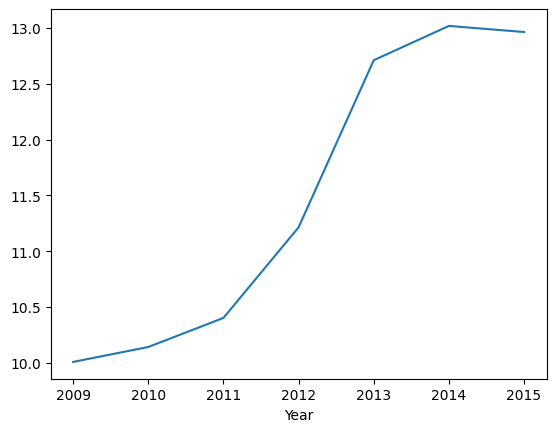

In [ ]:
df.groupby('Year')['fare_amount'].mean().plot()
plt.show()

In [19]:
df["WeekDay"]=df["key"].dt.weekday

In [23]:
df["WeekDay"]

0         3
1         4
2         0
3         4
4         3
         ..
199995    6
199996    4
199997    0
199998    2
199999    5
Name: WeekDay, Length: 199978, dtype: int32

<Axes: ylabel='fare_amount'>

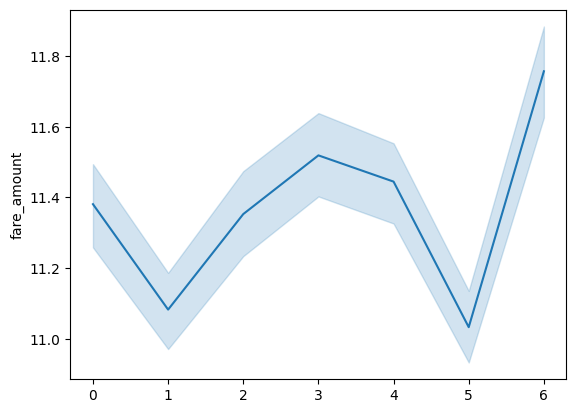

In [26]:
sns.lineplot(x=df["WeekDay"].values,y=df['fare_amount'])

In [27]:
df.groupby("WeekDay")["fare_amount"].mean()

WeekDay
0    11.381039
1    11.082397
2    11.352992
3    11.519246
4    11.444944
5    11.032638
6    11.757465
Name: fare_amount, dtype: float64

In [29]:
Year_FA=df.groupby("Year")["fare_amount"].mean().sort_values()

In [31]:
Year_FA.index

Index([2009, 2010, 2011, 2012, 2013, 2015, 2014], dtype='int32', name='Year')

seaborn.axisgrid.PairGrid

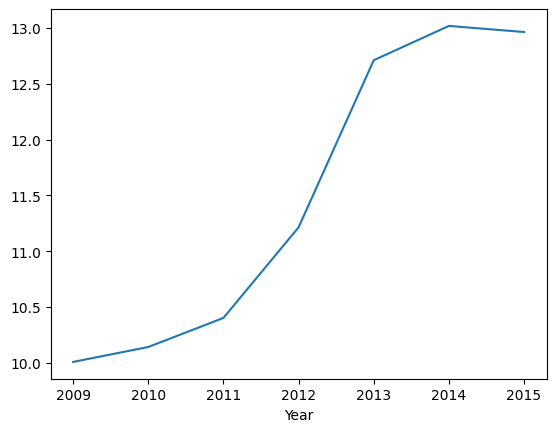

In [ ]:
sns.lineplot(x=Year_FA.index,y=Year_FA.values)
sns.

In [35]:
df.groupby("WeekDay")["fare_amount"].mean().sort_values()

WeekDay
5    11.032638
1    11.082397
2    11.352992
0    11.381039
4    11.444944
3    11.519246
6    11.757465
Name: fare_amount, dtype: float64

Conclution:     
  Average fare amount on the week day 5 is 11.032638   
  Average fare amount on the week day 6 is 11.757465    
  so if we increase the rides on the 6 week day to make more profit  

In [39]:
df.groupby("WeekDay")["passenger_count"].sum().sort_values()

WeekDay
0    41435
1    46460
6    46578
2    47491
3    49457
4    51656
5    53782
Name: passenger_count, dtype: int64

conclution :   
  Week 5 has 53782 (highest)  
  Week 0 has the lowest 41435 

<Axes: xlabel='WeekDay', ylabel='passenger_count'>

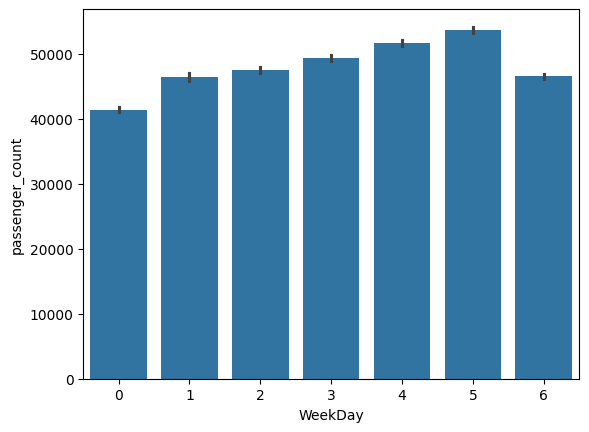

In [44]:
sns.barplot(x=df['WeekDay'],y=df['passenger_count'],estimator="sum")


In [ ]:
month wise which has more fare amount 
in that month which week day has more fare amount

In [66]:
df.groupby("Month")["fare_amount"].mean().sort_values()

Month
1     10.726200
2     10.938832
3     11.115826
7     11.161218
8     11.205358
4     11.339580
12    11.497182
6     11.606029
11    11.612201
5     11.681863
10    11.723333
9     11.791642
Name: fare_amount, dtype: float64

In [69]:
Month_nine=df[df["Month"]==9]

In [71]:
Month_nine.groupby("WeekDay")["fare_amount"].mean().sort_values()

WeekDay
0    11.501549
2    11.556635
1    11.570564
5    11.775171
3    11.974921
6    11.986818
4    12.113137
Name: fare_amount, dtype: float64